# **Exploratory Data Analysis for Clinical Experts**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
from pathlib import Path
import sys
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

from digit_fr.core.paths import path_from_root
df = pd.read_csv(path_from_root('data', 'raw', 'fed_recommenders_synthetic_dataset.csv'))
print(f"Dataset shape: {df.shape}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Dataset shape: (2000, 42)
Memory usage: 0.64 MB


## **Basic overview**
* Dataset metrics 
* Missing values

In [2]:
print(f"Dataset Length: {len(df)}")
print(f"Number of clients: {df['Client'].nunique()}")
print(f"Patients per client: {len(df) // df['Client'].nunique()}")
print(f"Features: {df.shape[1] - 1}")

print("\n \n Missing values:")
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_percent
}).sort_values('Missing %', ascending=False)
print(missing_df[missing_df['Missing %'] > 0])


Dataset Length: 2000
Number of clients: 10
Patients per client: 200
Features: 41

 
 Missing values:
                              Missing Count  Missing %
PartialBony_GingivalCoverage           1108      55.40
Surg_2_Subtype                         1014      50.70
Tooth_Mobility                           85       4.25
Bone_Density                             71       3.55


## **Target label distribution**

1. Simple Extraction: 493 (24.6%)
2. Surgical Extraction (Flap/Minor Bone): 986 (49.3%)
3. Coronectomy: 521 (26.1%)


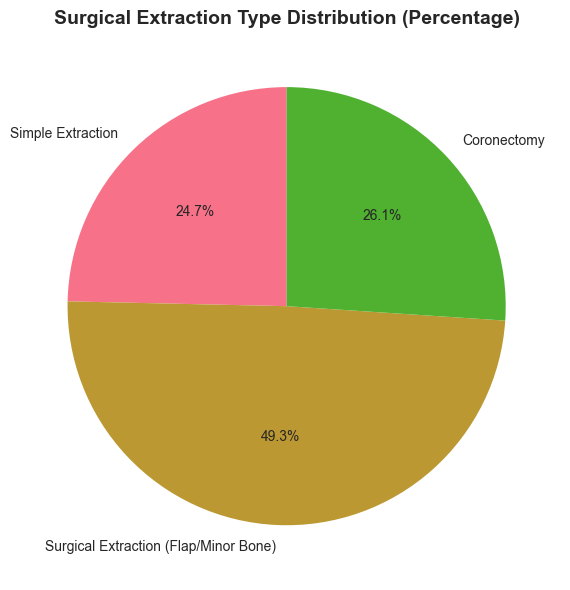

In [3]:
decision_labels = {
    1: 'Simple Extraction',
    2: 'Surgical Extraction (Flap/Minor Bone)',
    3: 'Coronectomy'
}

decision_counts = df['Surgical_Extraction_Type'].value_counts().sort_index()
decision_percentages = (decision_counts / len(df)) * 100

for decision, count in decision_counts.items():
    print(f"{decision}. {decision_labels[decision]}: {count} ({decision_percentages[decision]:.1f}%)")

fig, (ax1) = plt.subplots(1, figsize=(15, 6))
ax1.pie(decision_counts.values, labels=[decision_labels[i] for i in decision_counts.index], 
        autopct='%1.1f%%', startangle=90)
ax1.set_title('Surgical Extraction Type Distribution (Percentage)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## **Patient information**

<Axes: >

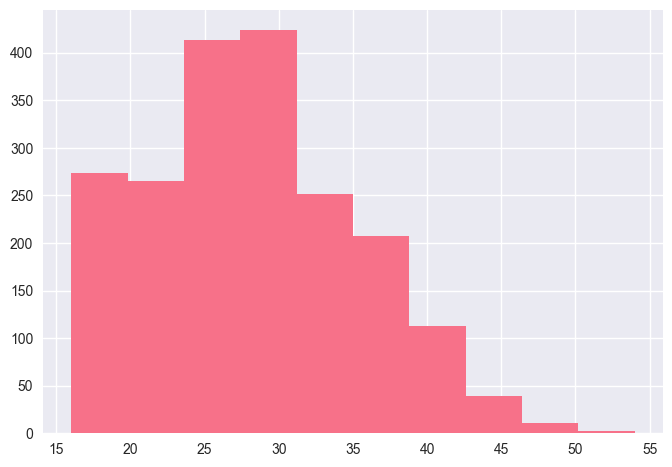

In [4]:
df['Age'].describe()
df['Age'].hist(bins=10)

## **Symptom distribution**

In [5]:
symptoms = ["Pain", "Swelling", "Trismus", "Pericoronitis", "Mandi_Maxi"]

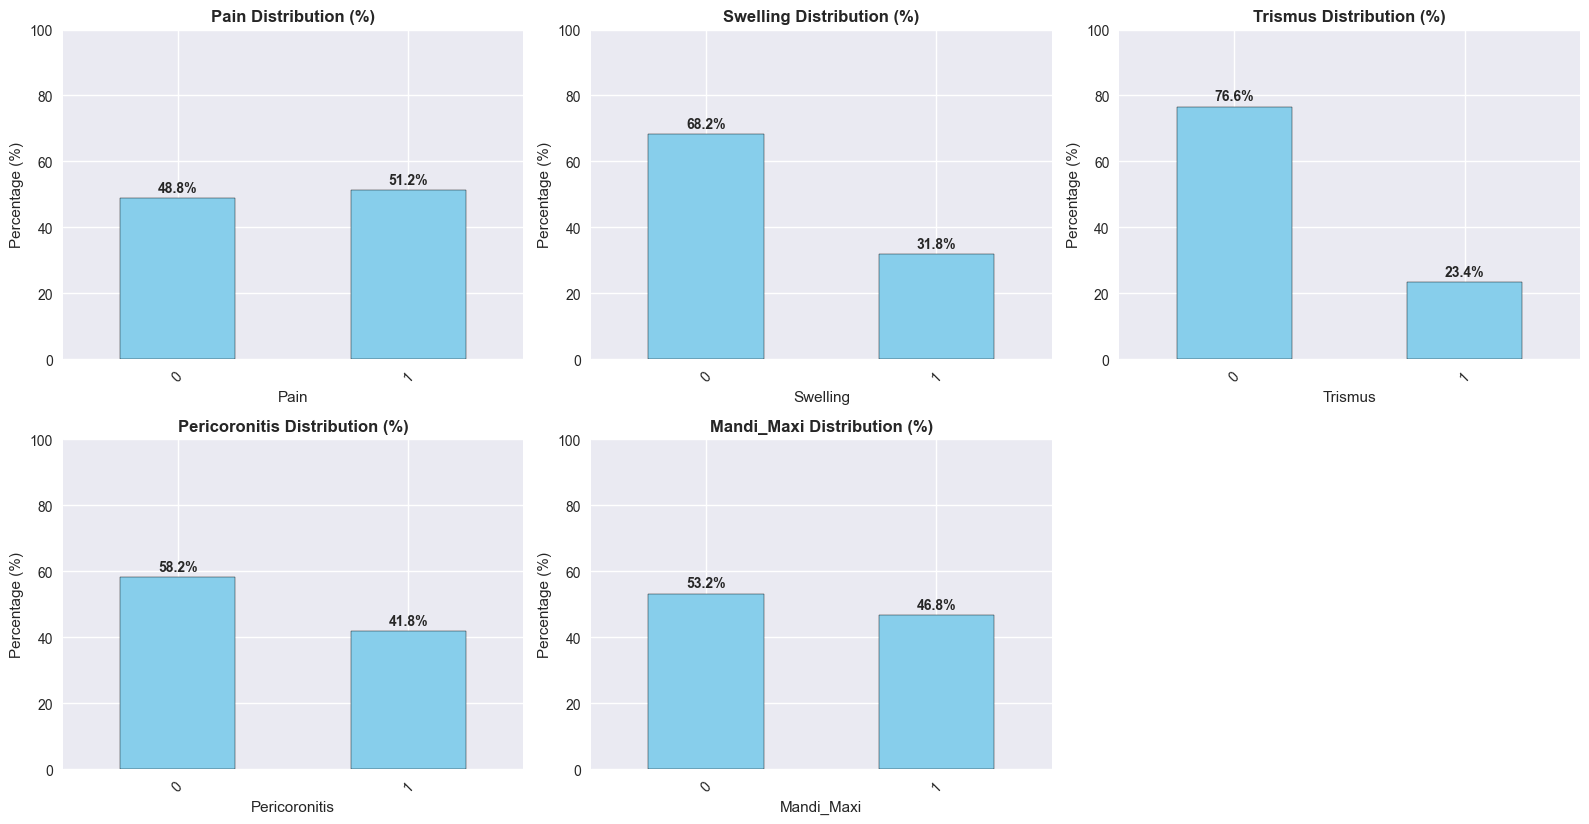

In [6]:
for feature in symptoms:
    value_counts = df[feature].value_counts().sort_index()
    percentages = (value_counts / len(df)) * 100


fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.ravel()

for i, feature in enumerate(symptoms):
    ax = axes[i]
    
    value_counts = df[feature].value_counts(normalize=True).sort_index() * 100
    bars = value_counts.plot(kind='bar', ax=ax, color='skyblue', edgecolor='black')
    
    ax.set_title(f'{feature} Distribution (%)', fontweight='bold', fontsize=12)
    ax.set_xlabel(feature)
    ax.set_ylabel('Percentage (%)')
    ax.set_ylim(0, 100)
    ax.tick_params(axis='x', rotation=45)
    
    for j, (val, pct) in enumerate(value_counts.items()):
        ax.text(
            j, pct + 1,           # position (x, y)
            f'{pct:.1f}%',        # text
            ha='center', va='bottom', fontsize=10, fontweight='bold'
        )

# Remove empty subplots
for j in range(len(symptoms), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Symptom percentages
Pain             51.2
Swelling         31.8
Trismus          23.4
Pericoronitis    41.8
Mandi_Maxi       46.8
dtype: float64


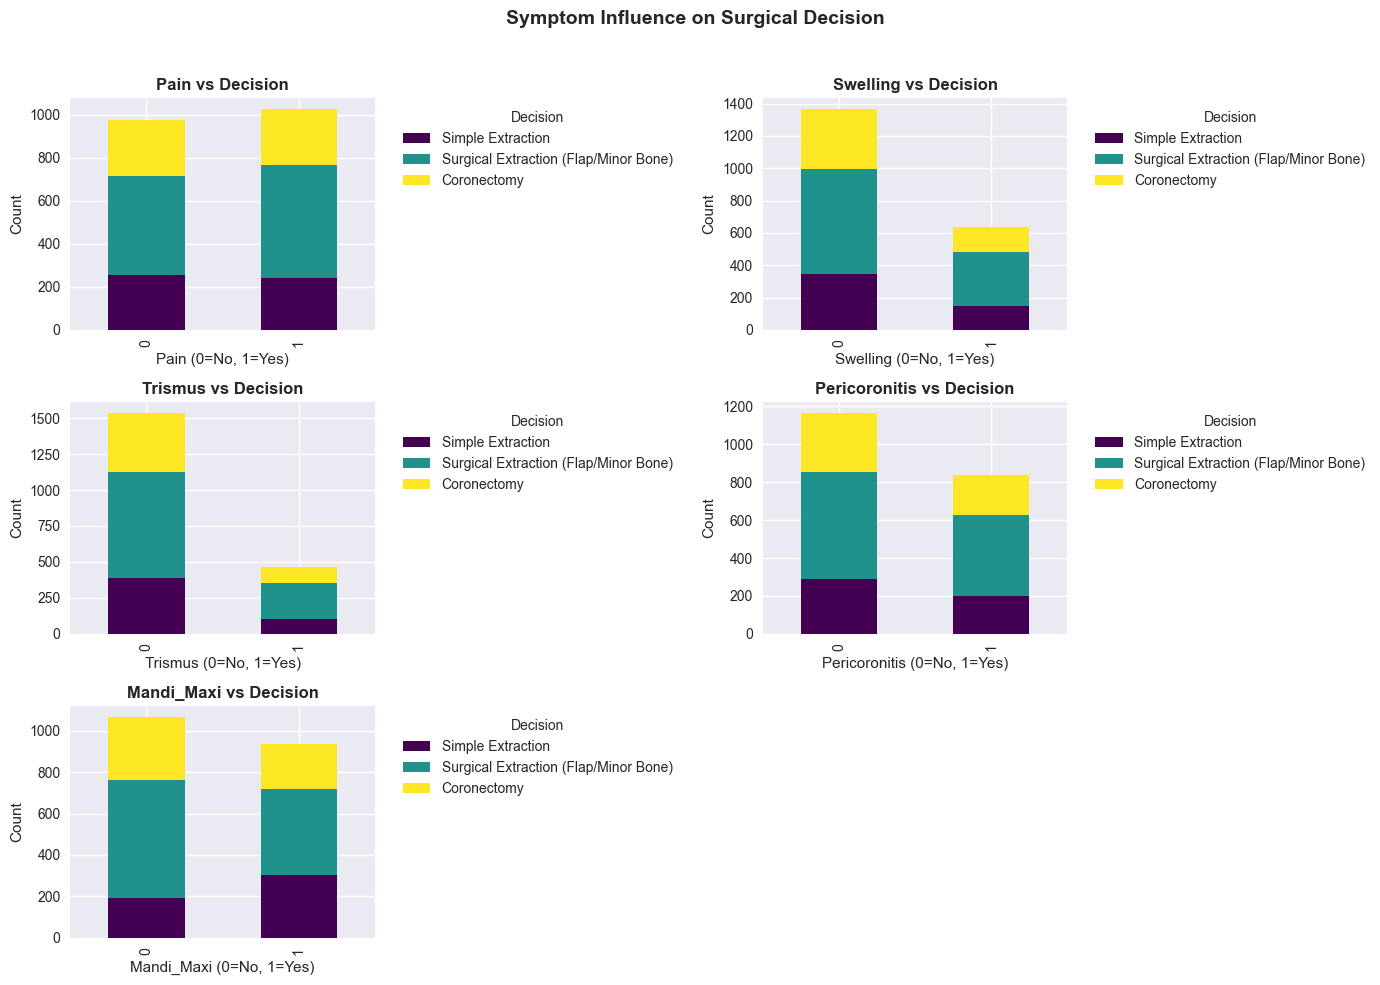

In [7]:
print("Symptom percentages")
symptom_prevalence = df[symptoms].mean() * 100
print(symptom_prevalence.round(1))

fig, axes = plt.subplots(3, 2, figsize=(14, 10))
axes = axes.ravel()

for i, symptom in enumerate(symptoms):
    ct = pd.crosstab(df[symptom], df["Surgical_Extraction_Type"])
    ct.columns = [decision_labels[c] for c in ct.columns]
    ct.plot(kind="bar", stacked=True, ax=axes[i], colormap="viridis")
    axes[i].set_title(f"{symptom} vs Decision", fontweight="bold")
    axes[i].set_xlabel(f"{symptom} (0=No, 1=Yes)")
    axes[i].set_ylabel("Count")
    axes[i].legend(title="Decision", bbox_to_anchor=(1.05, 1), loc='upper left')

for j in range(len(symptoms), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Symptom Influence on Surgical Decision", fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## **Anatomical features**

In [8]:
anatomical_features = [
    'Impaction_Depth', 'Proximity_Nerve', 'Tooth_Angulation', 
    'Root_Count', 'Root_Curvature', 'Bone_Density', 'Cyst'
]

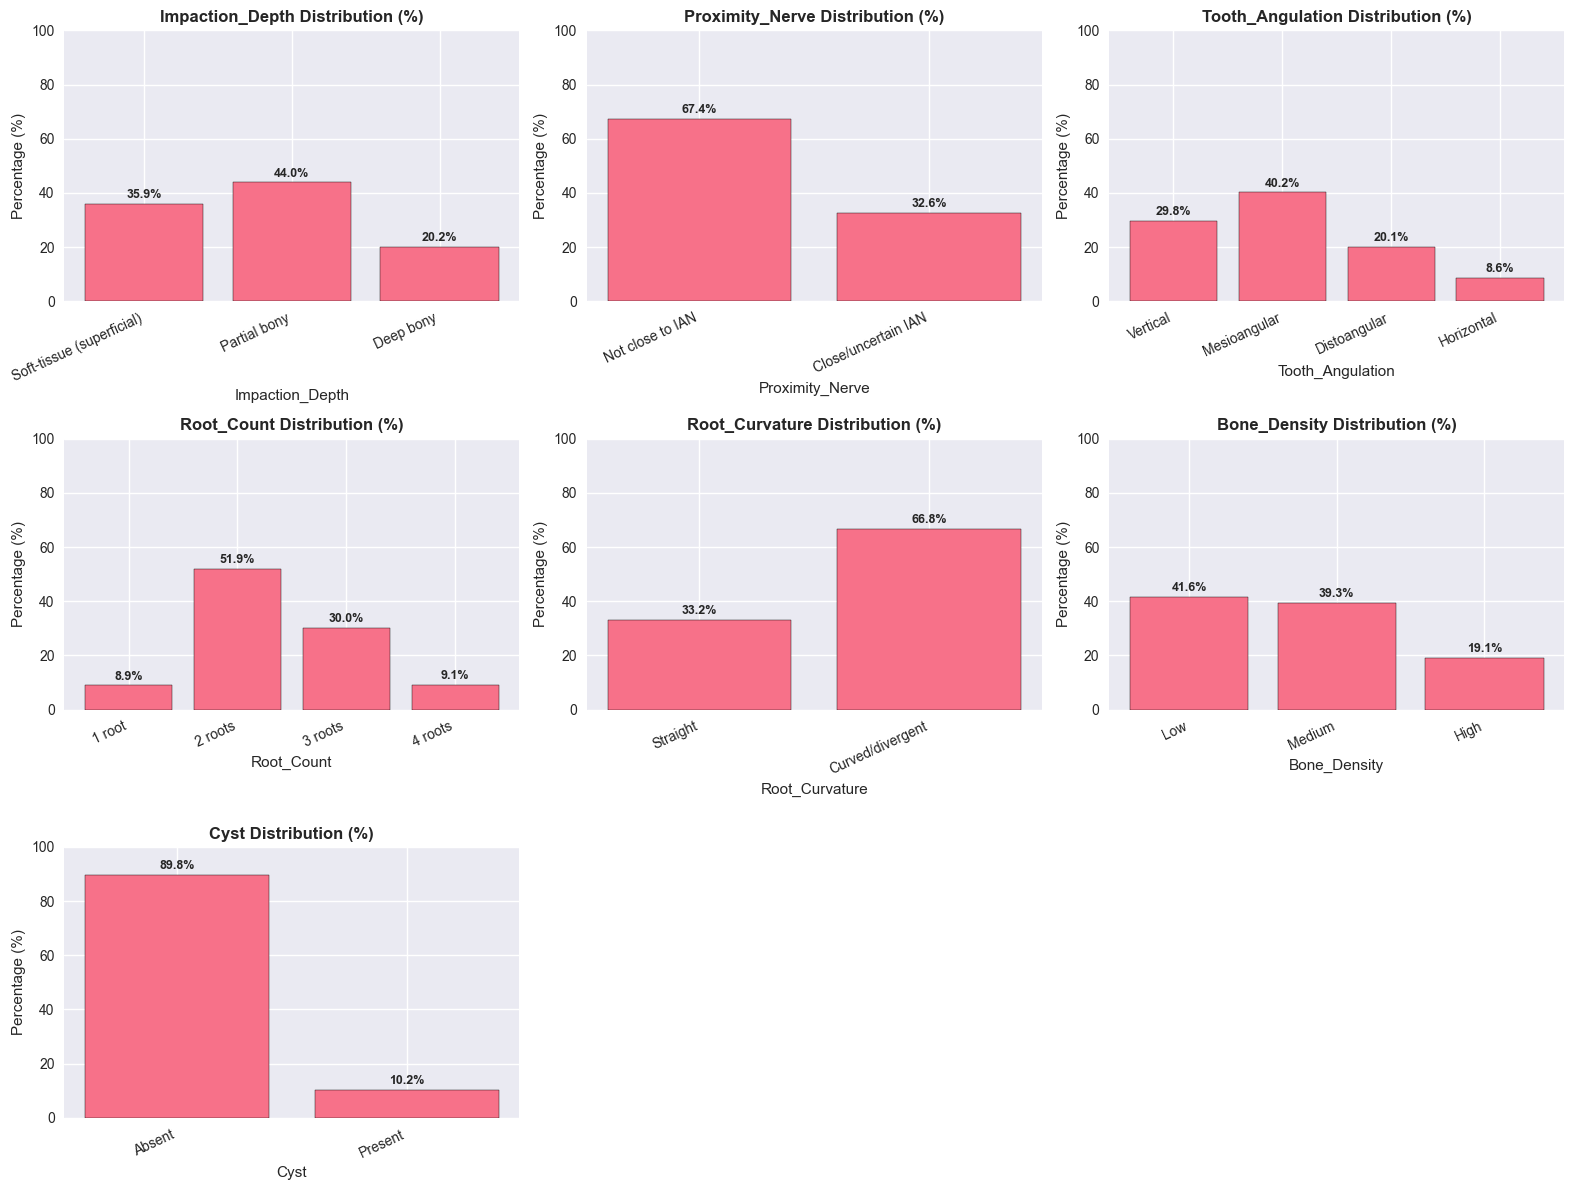

In [9]:
label_maps = {
    'Impaction_Depth': {1:'Soft-tissue (superficial)', 2:'Partial bony', 3:'Deep bony'},
    'Proximity_Nerve': {0:'Not close to IAN', 1:'Close/uncertain IAN'},
    'Tooth_Angulation': {1:'Vertical', 2:'Mesioangular', 3:'Distoangular', 4:'Horizontal'},
    'Root_Count': {1:'1 root', 2:'2 roots', 3:'3 roots', 4:'4 roots'},
    'Root_Curvature': {0:'Straight', 1:'Curved/divergent'},
    'Bone_Density': {1:'Low', 2:'Medium', 3:'High'},
    'Cyst': {0:'Absent', 1:'Present'},
}

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.ravel()

for i, feature in enumerate(anatomical_features):
    ax = axes[i]
    mapping = label_maps[feature]
    order = list(mapping.keys())

    vc = (df[feature].value_counts(normalize=True) * 100)
    vc = vc.reindex(order).fillna(0)

    bars = ax.bar(range(len(order)), vc.values, edgecolor='black')

    ax.set_title(f'{feature} Distribution (%)', fontweight='bold', fontsize=12)
    ax.set_xlabel(feature)
    ax.set_ylabel('Percentage (%)')
    ax.set_ylim(0, 100)
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels([mapping[k] for k in order], rotation=25, ha='right')

    for j, p in enumerate(bars):
        pct = vc.values[j]
        ax.text(p.get_x() + p.get_width()/2, p.get_height() + 1,
                f'{pct:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

for j in range(len(anatomical_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Impaction Depth Distribution (%):
depth
Partial bony    43.95
Soft tissue     35.90
Deep bony       20.15

Partial Bony Gingival Coverage (Depth = 2 only) (%):
PartialBony_GingivalCoverage_Label
Partially covered    60.38
Fully covered        39.62


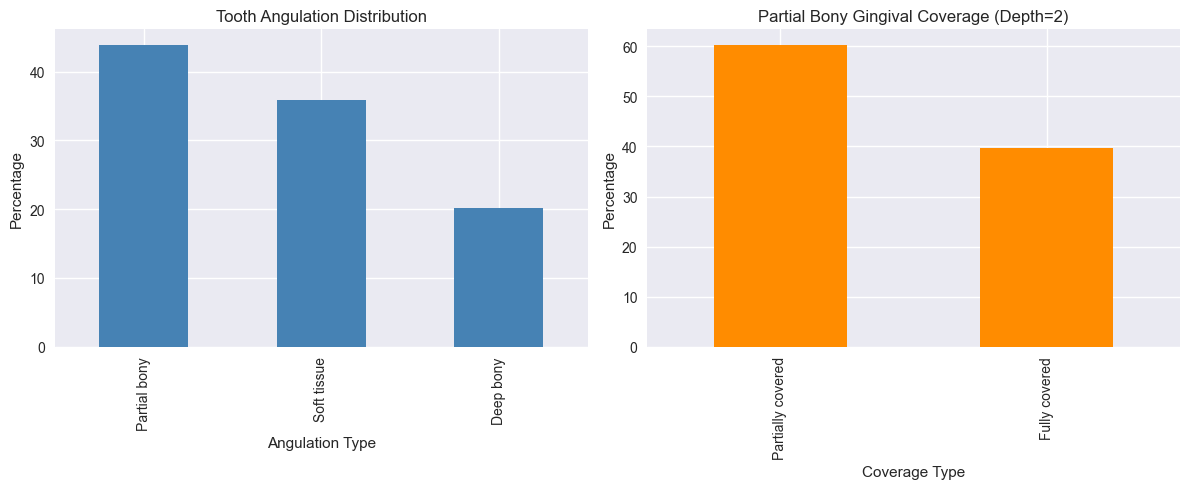

In [10]:
import pandas as pd

ang_map = {
    1: "Soft tissue",
    2: "Partial bony",
    3: "Deep bony",
}
df["depth"] = df["Impaction_Depth"].map(ang_map)

ang_counts = df["depth"].value_counts(normalize=True).mul(100).round(2)
print("Impaction Depth Distribution (%):")
print(ang_counts.to_string())

depth2 = df[df["Impaction_Depth"] == 2].copy()
cov_map = {0: "Fully covered", 1: "Partially covered"}
depth2["PartialBony_GingivalCoverage_Label"] = depth2["PartialBony_GingivalCoverage"].map(cov_map)

cov_counts = depth2["PartialBony_GingivalCoverage_Label"].value_counts(normalize=True).mul(100).round(2)
print("\nPartial Bony Gingival Coverage (Depth = 2 only) (%):")
print(cov_counts.to_string())

import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ang_counts.plot(kind="bar", color="steelblue", ax=ax[0])
ax[0].set_title("Tooth Angulation Distribution")
ax[0].set_ylabel("Percentage")
ax[0].set_xlabel("Angulation Type")

cov_counts.plot(kind="bar", color="darkorange", ax=ax[1])
ax[1].set_title("Partial Bony Gingival Coverage (Depth=2)")
ax[1].set_ylabel("Percentage")
ax[1].set_xlabel("Coverage Type")

plt.tight_layout()
plt.show()

In [11]:
count = df[(df["PartialBony_GingivalCoverage"] == 1)].shape[0]
count

535

In [12]:
count = df[(df["PartialBony_GingivalCoverage"] == 1) & (df["Removal_Indicated"] == 0)].shape[0]
print("Patients with gingival coverage = 1 and no removal indicated:", count)

Patients with gingival coverage = 1 and no removal indicated: 21


## **Risk factor Distributions**

Risk factor prevalence
Diabetes             10.5
Osteoporosis          0.7
Clotting_Disorder     2.3
Smoking              25.3
Bisphosphonates       0.5
dtype: float64
Risk factor vs. Surg. extraction type


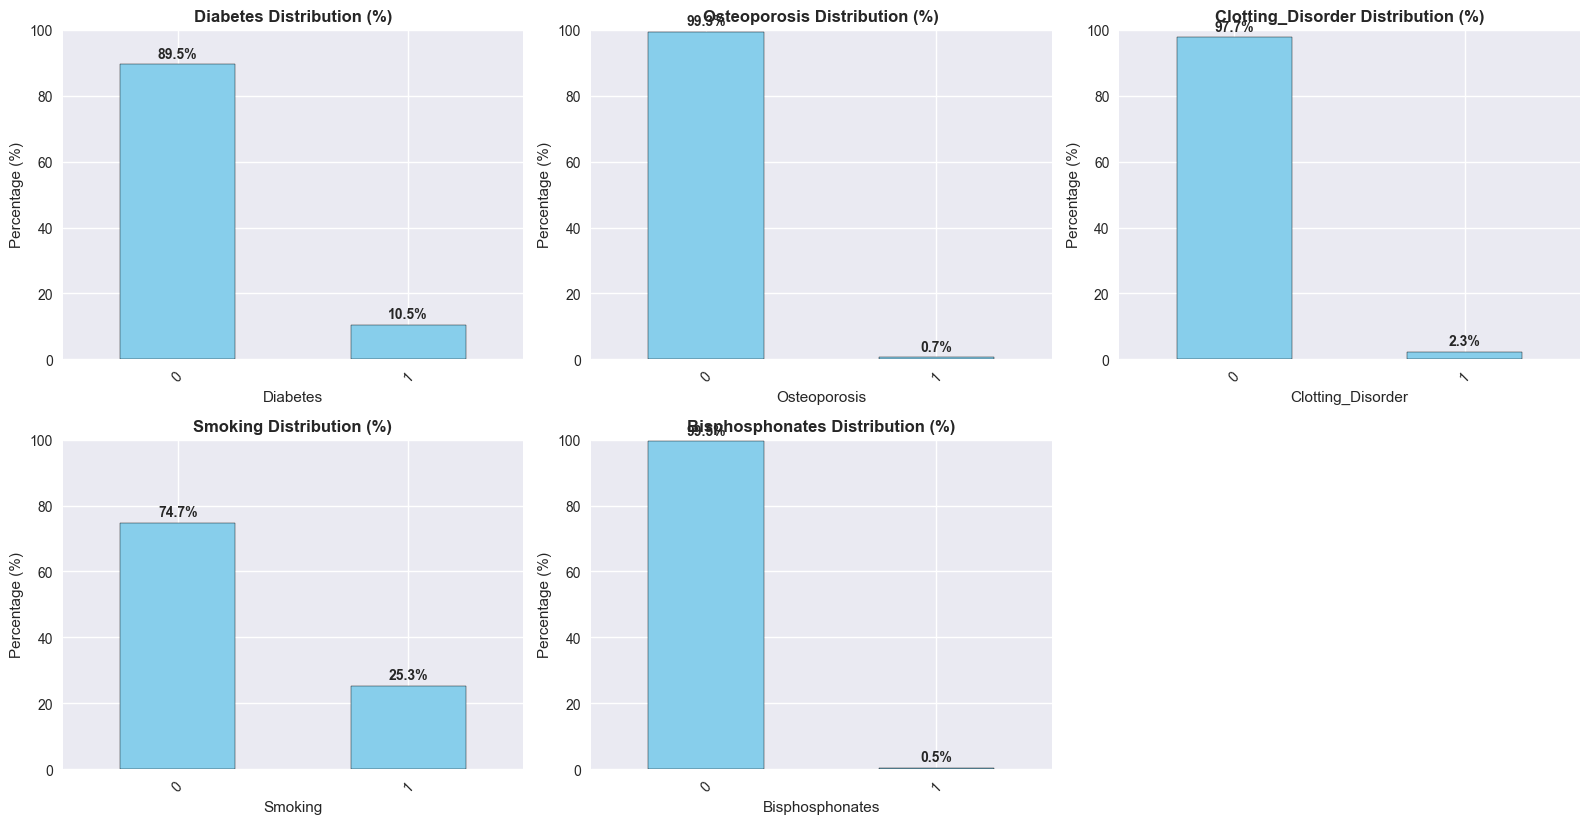

In [13]:
decision_order = [1, 2, 3]

risk_factors = ['Diabetes', 'Osteoporosis', 'Clotting_Disorder', 'Smoking', 'Bisphosphonates']

print("Risk factor prevalence")
risk_stats = df[risk_factors].mean(numeric_only=True) * 100
print(risk_stats.round(1))

print("Risk factor vs. Surg. extraction type")
for risk in risk_factors:
    tab = pd.crosstab(
        df[risk].fillna(0).astype(int), 
        df['Surgical_Extraction_Type'], 
        normalize='index'
    ) * 100

    tab = tab.reindex(columns=decision_order, fill_value=0.0)

for feature in risk_factors:
    value_counts = df[feature].value_counts().sort_index()
    percentages = (value_counts / len(df)) * 100


fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.ravel()

for i, feature in enumerate(risk_factors):
    ax = axes[i]
    
    value_counts = df[feature].value_counts(normalize=True).sort_index() * 100
    bars = value_counts.plot(kind='bar', ax=ax, color='skyblue', edgecolor='black')
    
    ax.set_title(f'{feature} Distribution (%)', fontweight='bold', fontsize=12)
    ax.set_xlabel(feature)
    ax.set_ylabel('Percentage (%)')
    ax.set_ylim(0, 100)
    ax.tick_params(axis='x', rotation=45)
    
    for j, (val, pct) in enumerate(value_counts.items()):
        ax.text(
            j, pct + 1,           # position (x, y)
            f'{pct:.1f}%',        # text
            ha='center', va='bottom', fontsize=10, fontweight='bold'
        )

# Remove empty subplots
for j in range(len(risk_factors), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## **Decision 2 Subtypes**

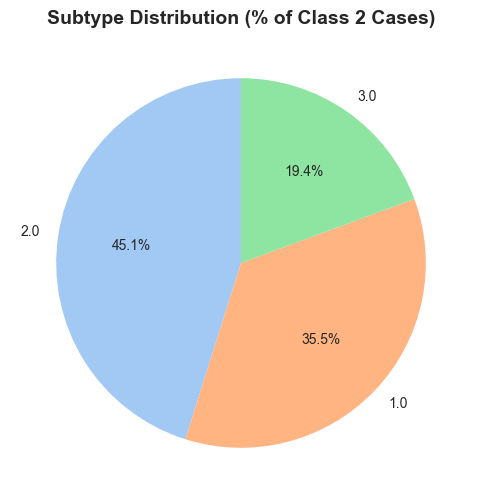

In [14]:
df_subtypes = df[df["Surgical_Extraction_Type"] == 2]
subtype_counts = df_subtypes["Surg_2_Subtype"].value_counts(normalize=True) * 100
plt.figure(figsize=(6, 6))
subtype_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=sns.color_palette("pastel"))
plt.ylabel('')
plt.title("Subtype Distribution (% of Class 2 Cases)", fontsize=14, fontweight='bold')
plt.show()

## **Correlation matrices**

## **

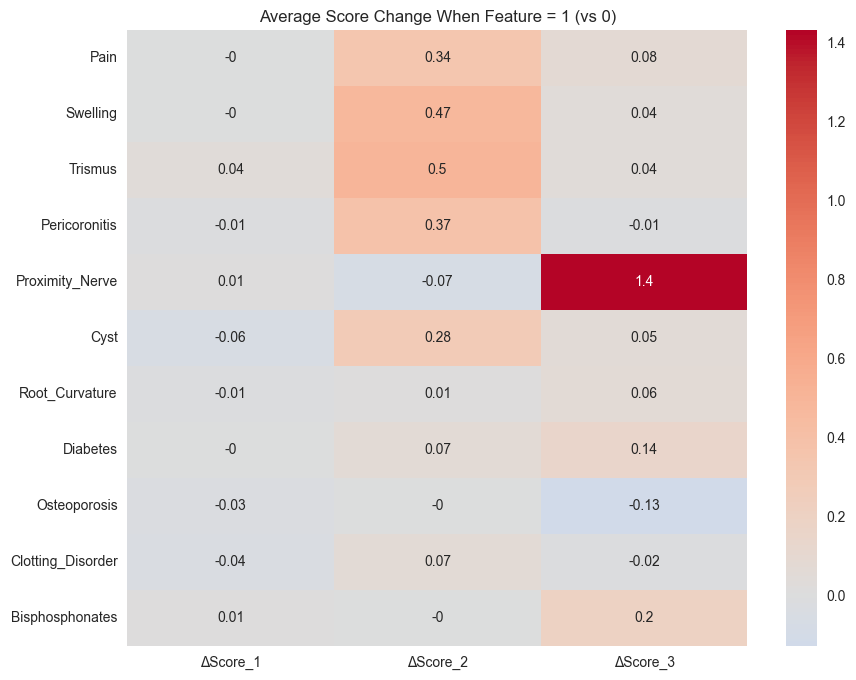

In [15]:
feature_cols = ["Pain", "Swelling", "Trismus", "Pericoronitis",
                "Proximity_Nerve", "Cyst", "Root_Curvature", "Diabetes",
                "Osteoporosis", "Clotting_Disorder", "Bisphosphonates"]

influence = {}
for feat in feature_cols:
    on = df[df[feat] == 1][["Score_1", "Score_2", "Score_3"]].mean()
    off = df[df[feat] == 0][["Score_1", "Score_2", "Score_3"]].mean()
    influence[feat] = (on - off).round(2)

influence_df = pd.DataFrame(influence).T
influence_df.columns = ["ΔScore_1", "ΔScore_2", "ΔScore_3"]

plt.figure(figsize=(10,8))
sns.heatmap(influence_df, annot=True, cmap="coolwarm", center=0)
plt.title("Average Score Change When Feature = 1 (vs 0)")
plt.show()

## **Interactions (if two features interact, how do they influence the decision?)**
* work in progress

In [16]:
slices = [
    ("Deep + Close IAN",             (df["Impaction_Depth"]==3) & (df["Proximity_Nerve"]==1)),
    ("Deep + NOT Close IAN",         (df["Impaction_Depth"]==3) & (df["Proximity_Nerve"]==0)),
    ("Horizontal + ≥3 roots (IAN not close)", (df["Tooth_Angulation"]==4) & (df["Root_Count"]>=3) & (df["Proximity_Nerve"]==0)),
    ("Horizontal + curvature (IAN not close)", (df["Tooth_Angulation"]==4) & (df["Root_Curvature"]==1) & (df["Proximity_Nerve"]==0)),
    ("Swelling + Trismus",           (df["Swelling"]==1) & (df["Trismus"]==1)),
    ("Cyst + High bone density",     (df["Cyst"]==1) & (df["Bone_Density"]==3)),
    ("Complete roots + close IAN",   (df["Root_Development"]==2) & (df["Proximity_Nerve"]==1)),
    ("Severe periodontitis",         (df["Periodontal_Status"]==3)),
]

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def slice_distribution(df, mask, title, show_plot=True):
    subset = df[mask]
    n = len(subset)
    if n == 0:
        print(f"{title}: no cases")
        return None

    # % per decision
    dist = (subset["Surgical_Extraction_Type"].value_counts(normalize=True) * 100).reindex([1,2,3]).fillna(0)
    baseline = (df["Surgical_Extraction_Type"].value_counts(normalize=True) * 100).reindex([1,2,3]).fillna(0)
    lift = dist - baseline

    print(f"\n {title} (N={n})")
    out = pd.DataFrame({"%": dist.round(1), "Lift_vs_overall (pp)": lift.round(1)})
    out.index = out.index.map(lambda k: f"{k}: {decision_labels[k]}")
    print(out)

    if show_plot:
        ax = dist.plot(kind="bar")
        ax.set_title(f"{title} (N={n})")
        ax.set_ylabel("Percentage of decisions")
        ax.set_ylim(0, 100)
        ax.set_xticklabels([decision_labels[k] for k in [1,2,3]], rotation=30, ha="right")
        for p, val in zip(ax.patches, dist.values):
            ax.annotate(f"{val:.1f}%", (p.get_x()+p.get_width()/2, p.get_height()),
                        ha="center", va="bottom", fontsize=9)
        plt.tight_layout()
        plt.show()
    return out

## **Risk Assessment Analysis**


In [18]:
risk_cols = ['Risk_AlveolarOsteitis', 'Risk_SecondaryInfection', 'Risk_NerveDysesthesia', 'Risk_Bleeding']

print("Counts by Mandi/Maxi (0=Mandibular, 1=Maxillary)")
print(df['Mandi_Maxi'].value_counts().rename({0: 'Mandibular (0)', 1: 'Maxillary (1)'}))
print("\n")

print("Summary statistics per group (mean, std, median, min, max, count):")
grouped_stats = (
    df.groupby('Mandi_Maxi')[risk_cols]
      .agg(['mean', 'std', 'median', 'min', 'max', 'count'])
      .round(4)
)
print(grouped_stats)
print("\n")

print("Mean ± SD table by group:")
means = df.groupby('Mandi_Maxi')[risk_cols].mean().round(4)
stds  = df.groupby('Mandi_Maxi')[risk_cols].std().round(4)
mean_sd_table = pd.concat({
    'Mean (0=Mand)': means.loc[0],
    'SD (0=Mand)':   stds.loc[0],
    'Mean (1=Maxi)': means.loc[1],
    'SD (1=Maxi)':   stds.loc[1],
}, axis=1)
print(mean_sd_table)
print("\n")

Counts by Mandi/Maxi (0=Mandibular, 1=Maxillary)
Mandi_Maxi
Mandibular (0)    1065
Maxillary (1)      935
Name: count, dtype: int64


Summary statistics per group (mean, std, median, min, max, count):
           Risk_AlveolarOsteitis                                       \
                            mean     std  median    min     max count   
Mandi_Maxi                                                              
0                         0.0636  0.0131  0.0632  0.036  0.0869  1065   
1                         0.0626  0.0129  0.0630  0.036  0.0869   935   

           Risk_SecondaryInfection                          ...  \
                              mean     std  median     min  ...   
Mandi_Maxi                                                  ...   
0                           0.0453  0.0146  0.0489  0.0243  ...   
1                           0.0385  0.0122  0.0426  0.0211  ...   

           Risk_NerveDysesthesia                   Risk_Bleeding          \
                     

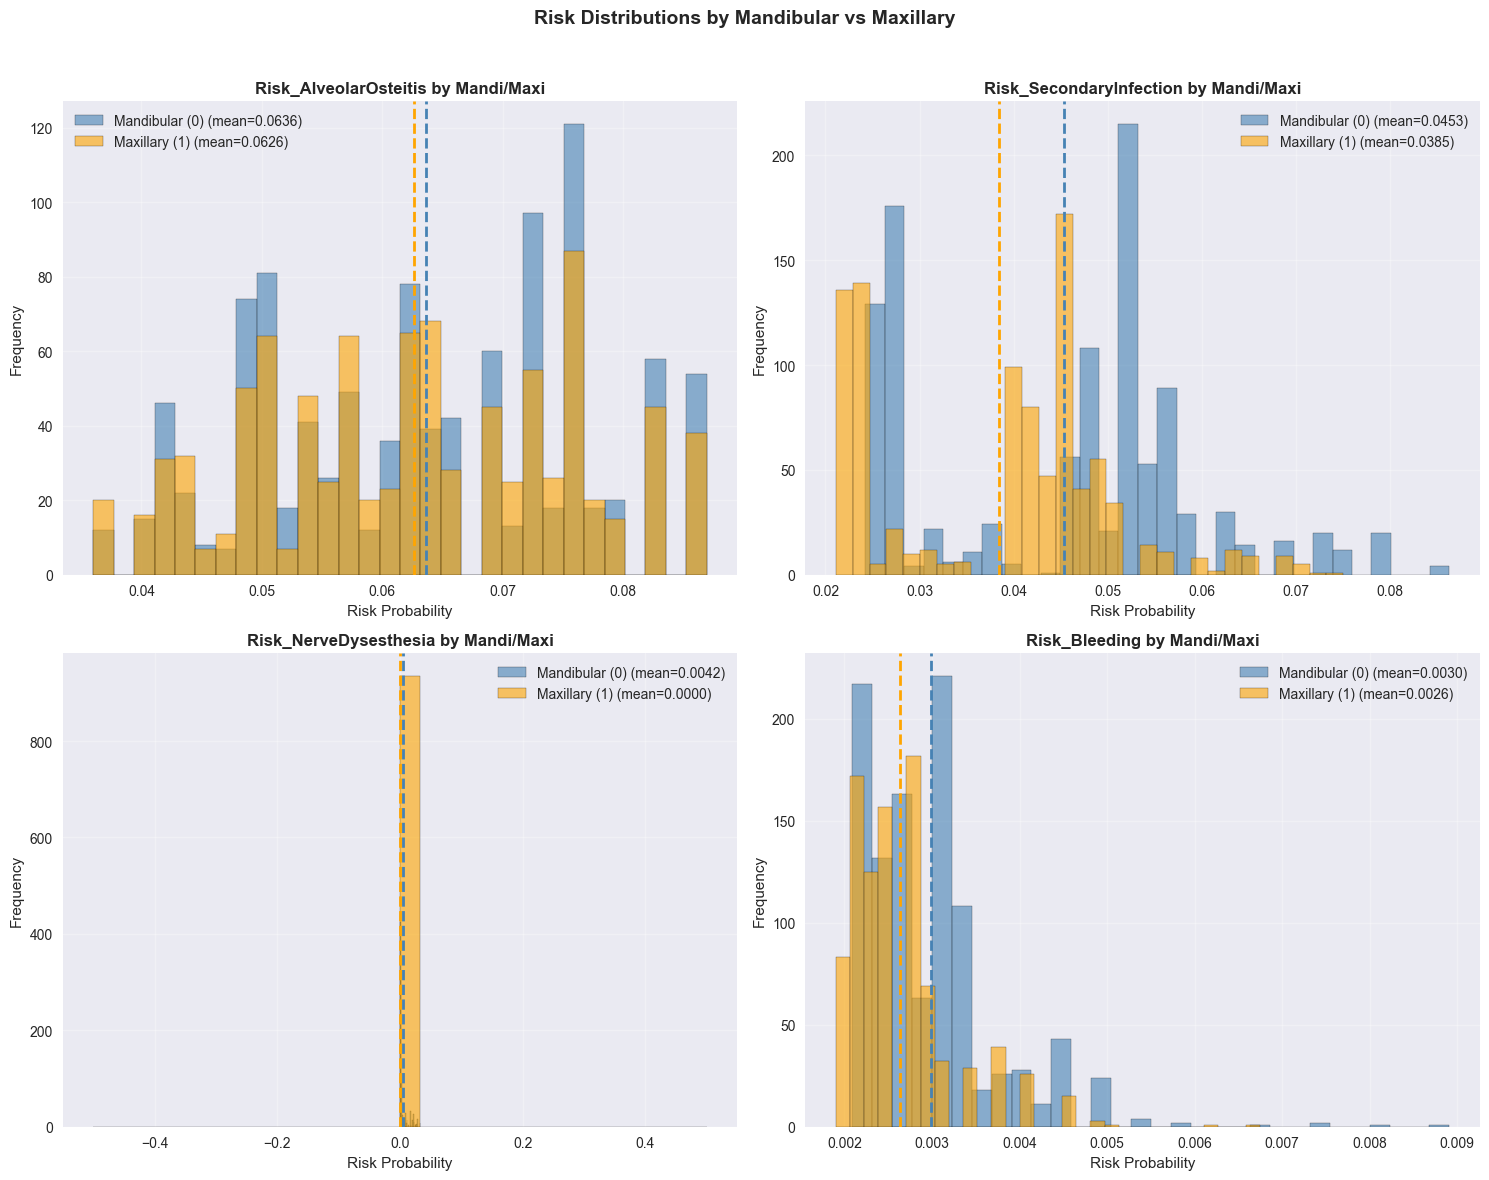

In [19]:
# Risk distribution plots by Mandi_Maxi (0=Mandibular, 1=Maxillary)
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.ravel()

colors = {0: 'steelblue', 1: 'orange'}
labels = {0: 'Mandibular (0)', 1: 'Maxillary (1)'}

for i, risk in enumerate(risk_cols):
    ax = axes[i]
    
    # Plot distributions for Mandi and Maxi separately
    for val in [0, 1]:
        subset = df[df['Mandi_Maxi'] == val]
        ax.hist(
            subset[risk], bins=30, alpha=0.6, 
            color=colors[val], edgecolor='black', 
            label=f'{labels[val]} (mean={subset[risk].mean():.4f})'
        )
        ax.axvline(
            subset[risk].mean(), color=colors[val], linestyle='--', linewidth=2
        )
    
    ax.set_title(f'{risk} by Mandi/Maxi', fontweight='bold', fontsize=12)
    ax.set_xlabel('Risk Probability')
    ax.set_ylabel('Frequency')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Risk Distributions by Mandibular vs Maxillary", fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## **Sanity check for Nerve damag and maxillary (should be close to zero for all patients)**

In [20]:
(df.loc[(df["Mandi_Maxi"] == 1) & (df["Risk_NerveDysesthesia"] > 0.000001)]).shape[0]

0

In [21]:
((df["Mandi_Maxi"] == 1) & (df["Risk_NerveDysesthesia"] > 0.0000001)).mean() * 100

0.0

Risk Correlations:
                         Risk_AlveolarOsteitis  Risk_SecondaryInfection  \
Risk_AlveolarOsteitis                    1.000                    0.371   
Risk_SecondaryInfection                  0.371                    1.000   
Risk_NerveDysesthesia                    0.118                    0.249   
Risk_Bleeding                            0.260                    0.314   

                         Risk_NerveDysesthesia  Risk_Bleeding  
Risk_AlveolarOsteitis                    0.118          0.260  
Risk_SecondaryInfection                  0.249          0.314  
Risk_NerveDysesthesia                    1.000          0.208  
Risk_Bleeding                            0.208          1.000  


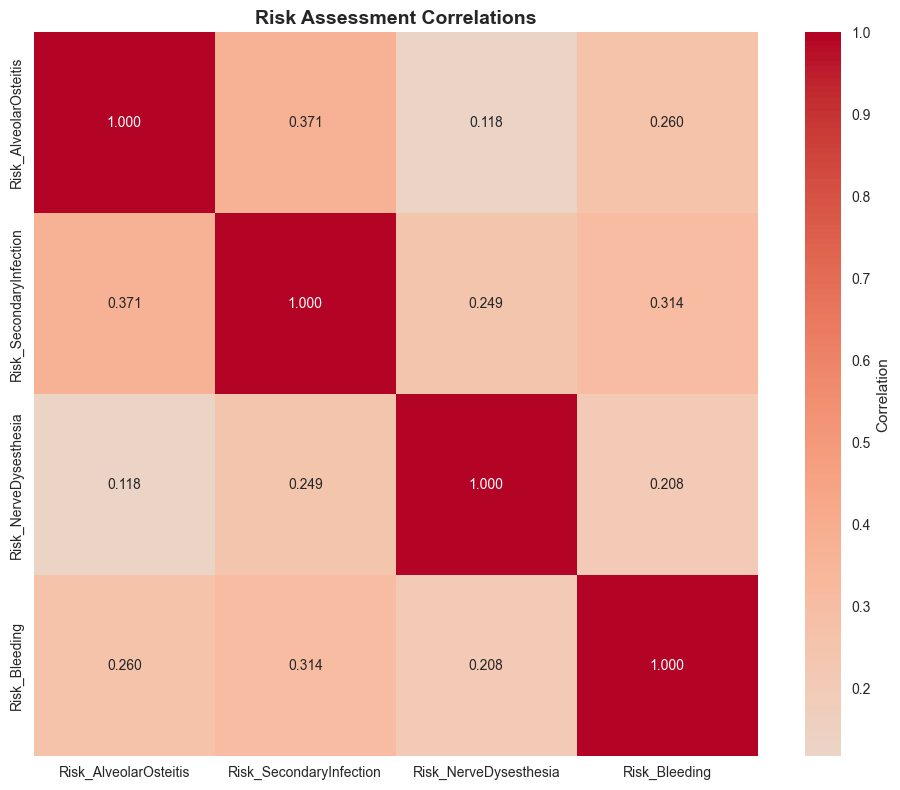


Risk Assessment by Key Factors:

Pericoronitis:
  Risk_AlveolarOsteitis: Yes=0.0665, No=0.0607, Δ=0.0058
  Risk_SecondaryInfection: Yes=0.0421, No=0.0421, Δ=0.0000
  Risk_NerveDysesthesia: Yes=0.0022, No=0.0023, Δ=-0.0002
  Risk_Bleeding: Yes=0.0028, No=0.0028, Δ=0.0000

Cyst:
  Risk_AlveolarOsteitis: Yes=0.0638, No=0.0631, Δ=0.0007
  Risk_SecondaryInfection: Yes=0.0572, No=0.0404, Δ=0.0168
  Risk_NerveDysesthesia: Yes=0.0025, No=0.0022, Δ=0.0003
  Risk_Bleeding: Yes=0.0029, No=0.0028, Δ=0.0001

Pain:
  Risk_AlveolarOsteitis: Yes=0.0631, No=0.0632, Δ=-0.0001
  Risk_SecondaryInfection: Yes=0.0425, No=0.0417, Δ=0.0009
  Risk_NerveDysesthesia: Yes=0.0023, No=0.0022, Δ=0.0001
  Risk_Bleeding: Yes=0.0029, No=0.0028, Δ=0.0001

Proximity_Nerve:
  Risk_AlveolarOsteitis: Yes=0.0624, No=0.0635, Δ=-0.0011
  Risk_SecondaryInfection: Yes=0.0421, No=0.0421, Δ=-0.0000
  Risk_NerveDysesthesia: Yes=0.0056, No=0.0006, Δ=0.0050
  Risk_Bleeding: Yes=0.0028, No=0.0028, Δ=-0.0001

Impaction_Depth:
  Risk_A

In [22]:
# Risk correlation analysis
print("Risk Correlations:")
print("=" * 30)
risk_corr = df[risk_cols].corr()
print(risk_corr.round(3))

# Risk correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(risk_corr, annot=True, cmap='coolwarm', center=0, 
            square=True, fmt='.3f', cbar_kws={'label': 'Correlation'})
plt.title('Risk Assessment Correlations', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

# Risk vs key factors
print("\nRisk Assessment by Key Factors:")
print("=" * 40)

key_factors = ['Pericoronitis', 'Cyst', 'Pain', 'Proximity_Nerve', 'Impaction_Depth']
for factor in key_factors:
    if factor in df.columns:
        print(f"\n{factor}:")
        for risk in risk_cols:
            factor_1 = df[df[factor] == 1][risk].mean()
            factor_0 = df[df[factor] == 0][risk].mean()
            diff = factor_1 - factor_0
            print(f"  {risk}: Yes={factor_1:.4f}, No={factor_0:.4f}, Δ={diff:.4f}")


## **Removal Indication Analysis**


Removal Indication Summary:
Overall removal rate: 0.929 (92.9%)

Removal probability statistics:
count    2000.0000
mean        0.9299
std         0.1511
min         0.2155
25%         0.9995
50%         1.0000
75%         1.0000
max         1.0000
Name: Removal_Prob, dtype: float64

Removal rate by client:
Client 1: 0.915 (91.5%)
Client 2: 0.920 (92.0%)
Client 3: 0.915 (91.5%)
Client 4: 0.965 (96.5%)
Client 5: 0.920 (92.0%)
Client 6: 0.900 (90.0%)
Client 7: 0.920 (92.0%)
Client 8: 0.935 (93.5%)
Client 9: 0.955 (95.5%)
Client 10: 0.945 (94.5%)

Removal indication vs Surgical Decision:
         Simple Extraction  Surgical Extraction (Flap/Minor Bone)  Coronectomy
Monitor                5.5                                    7.1          8.6
Remove                94.5                                   92.9         91.4


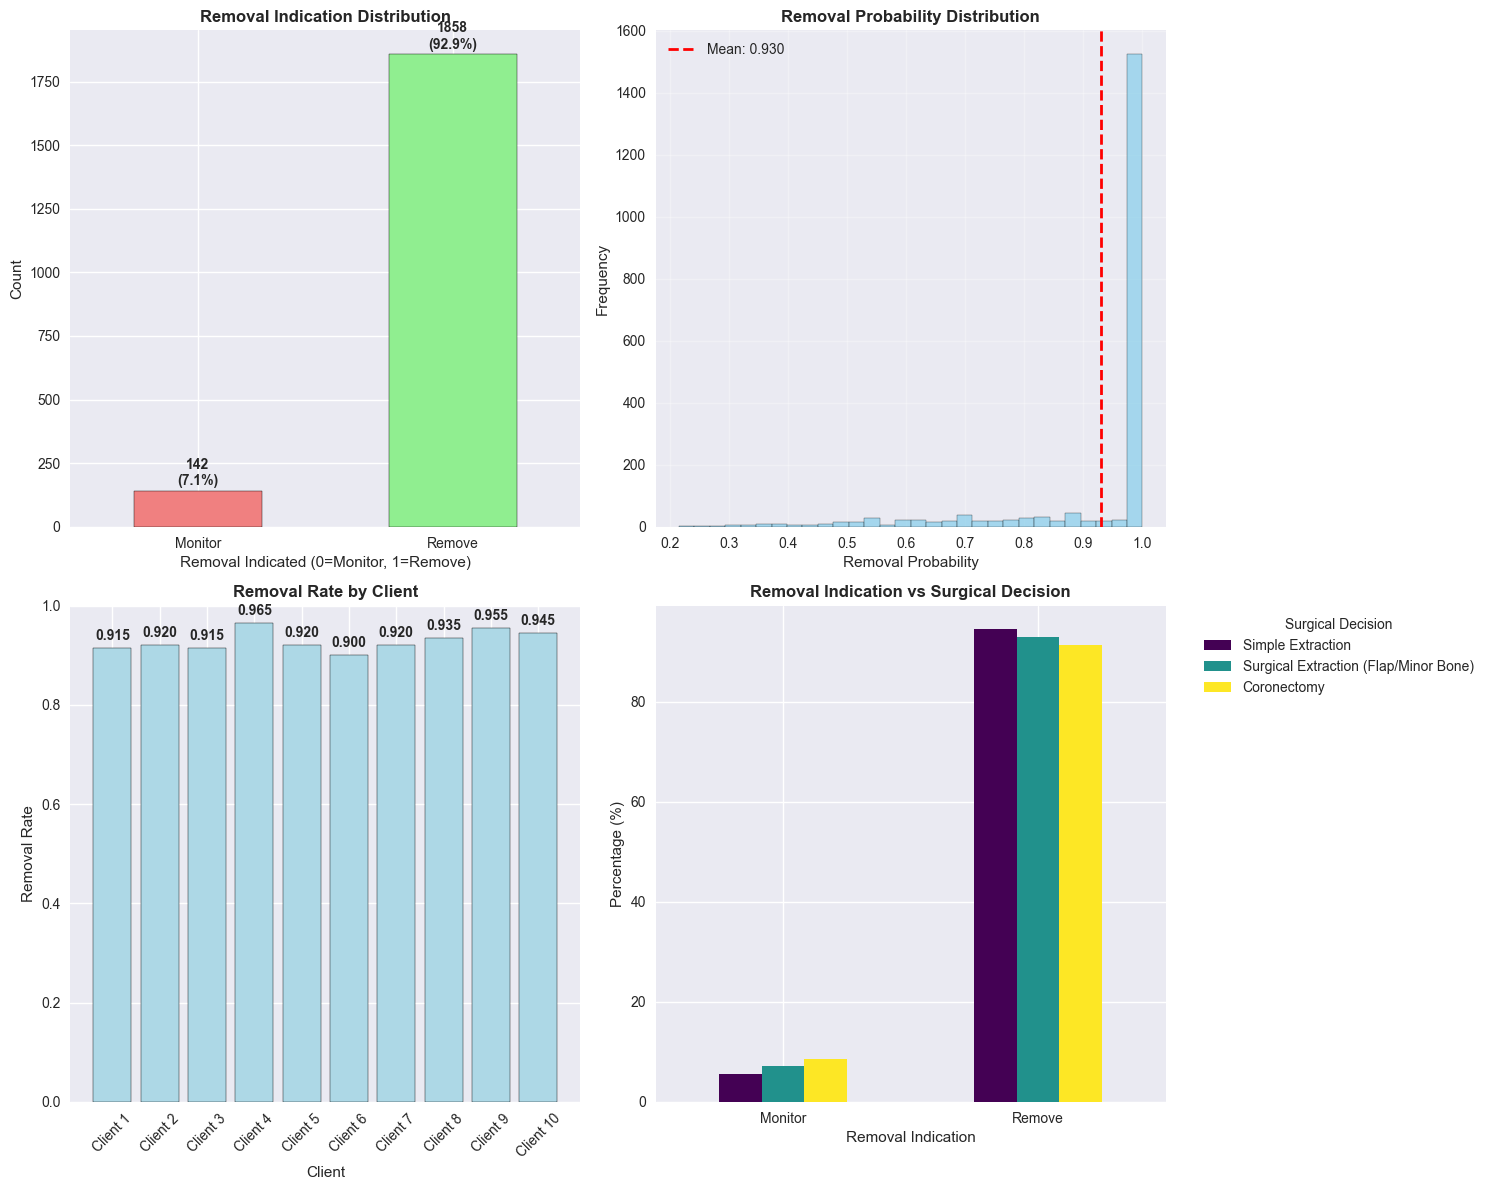

In [23]:
# Removal indication statistics
print("Removal Indication Summary:")
print("=" * 40)
removal_rate = df['Removal_Indicated'].mean()
print(f"Overall removal rate: {removal_rate:.3f} ({removal_rate*100:.1f}%)")

print(f"\nRemoval probability statistics:")
removal_prob_stats = df['Removal_Prob'].describe()
print(removal_prob_stats.round(4))

# Removal rate by client
print(f"\nRemoval rate by client:")
for client in sorted(df['Client'].unique()):
    client_data = df[df['Client'] == client]
    client_rate = client_data['Removal_Indicated'].mean()
    print(f"Client {client}: {client_rate:.3f} ({client_rate*100:.1f}%)")

# Removal indication vs surgical decision
print(f"\nRemoval indication vs Surgical Decision:")
removal_decision_crosstab = pd.crosstab(df['Removal_Indicated'], df['Surgical_Extraction_Type'], 
                                       normalize='columns') * 100
removal_decision_crosstab.columns = [decision_labels[c] for c in removal_decision_crosstab.columns]
removal_decision_crosstab.index = ['Monitor', 'Remove']
print(removal_decision_crosstab.round(1))

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Removal indication distribution
ax1 = axes[0, 0]
removal_counts = df['Removal_Indicated'].value_counts().sort_index()  # Sort by index (0, 1)
removal_counts.plot(kind='bar', ax=ax1, color=['lightcoral', 'lightgreen'], edgecolor='black')
ax1.set_title('Removal Indication Distribution', fontweight='bold')
ax1.set_xlabel('Removal Indicated (0=Monitor, 1=Remove)')
ax1.set_ylabel('Count')
ax1.set_xticklabels(['Monitor', 'Remove'], rotation=0)
for i, v in enumerate(removal_counts.values):
    ax1.text(i, v + 10, f'{v}\n({v/len(df)*100:.1f}%)', ha='center', va='bottom', fontweight='bold')

# Removal probability distribution
ax2 = axes[0, 1]
ax2.hist(df['Removal_Prob'], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
ax2.axvline(df['Removal_Prob'].mean(), color='red', linestyle='--', linewidth=2, 
           label=f'Mean: {df["Removal_Prob"].mean():.3f}')
ax2.set_title('Removal Probability Distribution', fontweight='bold')
ax2.set_xlabel('Removal Probability')
ax2.set_ylabel('Frequency')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Removal rate by client
ax3 = axes[1, 0]
client_removal_rates = []
client_labels = []
for client in sorted(df['Client'].unique()):
    client_data = df[df['Client'] == client]
    client_rate = client_data['Removal_Indicated'].mean()
    client_removal_rates.append(client_rate)
    client_labels.append(f'Client {client}')

bars = ax3.bar(range(len(client_labels)), client_removal_rates, 
               color='lightblue', edgecolor='black')
ax3.set_title('Removal Rate by Client', fontweight='bold')
ax3.set_xlabel('Client')
ax3.set_ylabel('Removal Rate')
ax3.set_xticks(range(len(client_labels)))
ax3.set_xticklabels(client_labels, rotation=45)
ax3.set_ylim(0, 1)
for i, v in enumerate(client_removal_rates):
    ax3.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

# Removal indication vs surgical decision heatmap
ax4 = axes[1, 1]
removal_decision_crosstab.plot(kind='bar', ax=ax4, colormap='viridis')
ax4.set_title('Removal Indication vs Surgical Decision', fontweight='bold')
ax4.set_xlabel('Removal Indication')
ax4.set_ylabel('Percentage (%)')
ax4.legend(title='Surgical Decision', bbox_to_anchor=(1.05, 1), loc='upper left')
ax4.set_xticklabels(['Monitor', 'Remove'], rotation=0)

plt.tight_layout()
plt.show()


Removal Indication by Key Factors:
Pericoronitis: Yes=0.977, No=0.894, Δ=0.083
Cyst: Yes=0.990, No=0.922, Δ=0.068
Pain: Yes=0.966, No=0.890, Δ=0.075
Swelling: Yes=0.978, No=0.906, Δ=0.072
Trismus: Yes=0.961, No=0.919, Δ=0.042
Proximity_Nerve: Yes=0.885, No=0.950, Δ=-0.065
Impaction_Depth: Yes=0.870, No=nan, Δ=nan

Risk Assessment vs Removal Indication:
Risk_AlveolarOsteitis: Monitor=0.0598, Remove=0.0634, Δ=0.0036
Risk_SecondaryInfection: Monitor=0.0337, Remove=0.0427, Δ=0.0090
Risk_NerveDysesthesia: Monitor=0.0026, Remove=0.0022, Δ=-0.0004
Risk_Bleeding: Monitor=0.0030, Remove=0.0028, Δ=-0.0002

Multi-task Target Correlations:
                          Surgical_Extraction_Type  Removal_Indicated  \
Surgical_Extraction_Type                     1.000             -0.044   
Removal_Indicated                           -0.044              1.000   
Removal_Prob                                -0.050              0.594   
Risk_AlveolarOsteitis                        0.180              0.070   

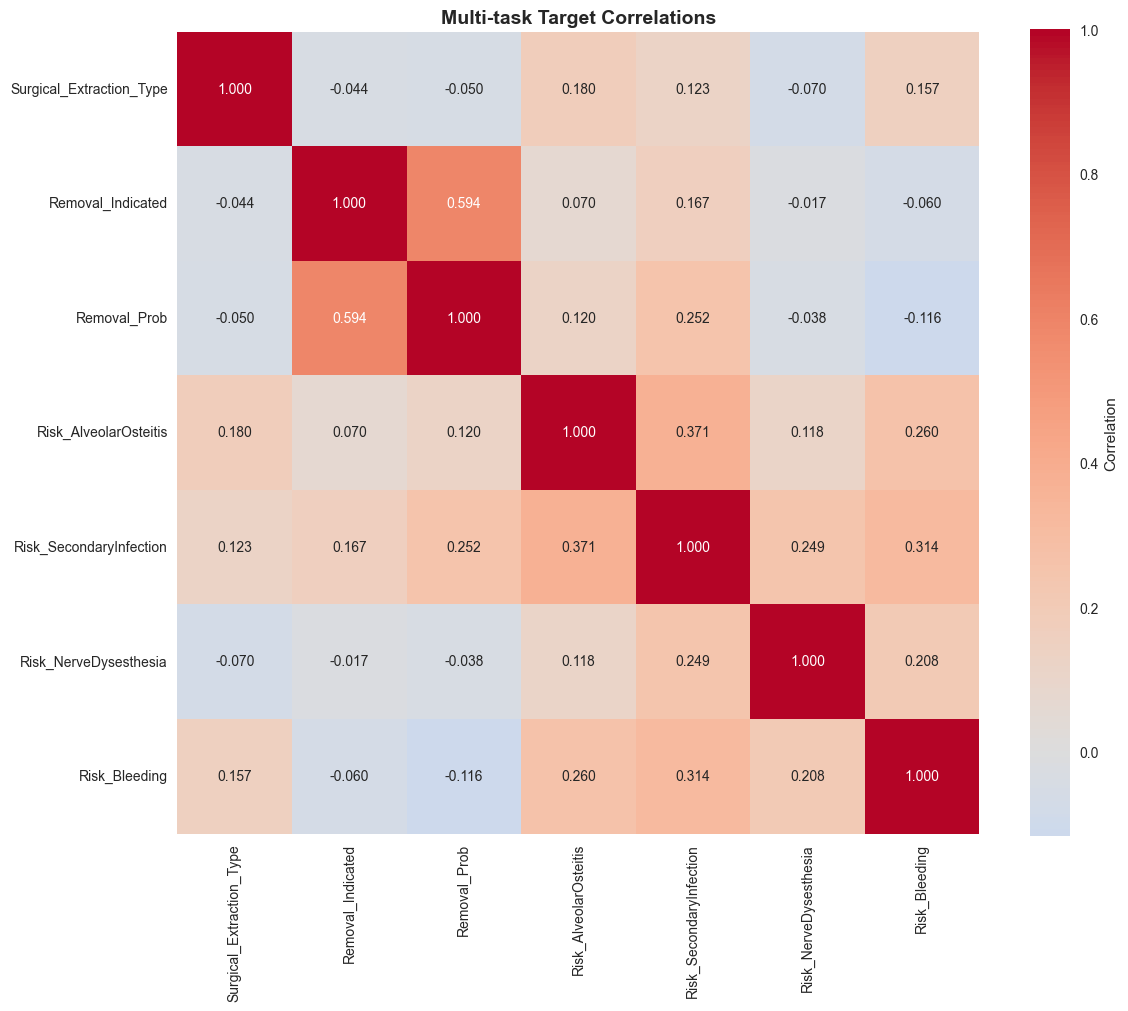

In [24]:
# Removal indication by key factors
print("Removal Indication by Key Factors:")
print("=" * 40)

key_factors = ['Pericoronitis', 'Cyst', 'Pain', 'Swelling', 'Trismus', 'Proximity_Nerve', 'Impaction_Depth']
for factor in key_factors:
    if factor in df.columns:
        factor_1 = df[df[factor] == 1]['Removal_Indicated'].mean()
        factor_0 = df[df[factor] == 0]['Removal_Indicated'].mean()
        diff = factor_1 - factor_0
        print(f"{factor}: Yes={factor_1:.3f}, No={factor_0:.3f}, Δ={diff:.3f}")

# Risk vs removal indication
print(f"\nRisk Assessment vs Removal Indication:")
print("=" * 45)
for risk in risk_cols:
    monitor_risk = df[df['Removal_Indicated'] == 0][risk].mean()
    remove_risk = df[df['Removal_Indicated'] == 1][risk].mean()
    diff = remove_risk - monitor_risk
    print(f"{risk}: Monitor={monitor_risk:.4f}, Remove={remove_risk:.4f}, Δ={diff:.4f}")

# Multi-task correlation analysis
print(f"\nMulti-task Target Correlations:")
print("=" * 35)
multi_task_cols = ['Surgical_Extraction_Type', 'Removal_Indicated', 'Removal_Prob'] + risk_cols
multi_task_corr = df[multi_task_cols].corr()
print(multi_task_corr.round(3))

# Multi-task correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(multi_task_corr, annot=True, cmap='coolwarm', center=0, 
            square=True, fmt='.3f', cbar_kws={'label': 'Correlation'})
plt.title('Multi-task Target Correlations', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()


## **High-Risk Patient Analysis**


In [25]:
# High-risk patient analysis - Top 3 patients for each risk type
risk_cols = ['Risk_AlveolarOsteitis', 'Risk_SecondaryInfection', 'Risk_NerveDysesthesia', 'Risk_Bleeding']

print("🔍 TOP 3 HIGHEST-RISK PATIENTS FOR EACH RISK TYPE")
print("=" * 60)

for risk in risk_cols:
    print(f"\n📊 {risk}:")
    print("-" * 50)
    
    # Get top 3 patients for this risk
    top_3 = df.nlargest(3, risk)[['Client', 'Patient', 'Age', 'Sex', risk, 'Surgical_Extraction_Type', 'Removal_Indicated',
                                  'Pericoronitis', 'Cyst', 'Pain', 'Swelling', 'Trismus', 
                                  'Impaction_Depth', 'Proximity_Nerve', 'Tooth_Angulation']]
    
    for idx, row in top_3.iterrows():
        print(f"Patient {row['Patient']} (Client {row['Client']}):")
        print(f"  Risk: {row[risk]:.4f}")
        print(f"  Age: {row['Age']}, Sex: {'Female' if row['Sex'] == 1 else 'Male'}")
        print(f"  Surg. extraction type: {decision_labels[row['Surgical_Extraction_Type']]}")
        print(f"  Removal: {'Remove' if row['Removal_Indicated'] == 1 else 'Monitor'}")
        
        # Show key risk factors
        risk_factors = []
        if row['Pericoronitis'] == 1: risk_factors.append("Pericoronitis")
        if row['Cyst'] == 1: risk_factors.append("Cyst")
        if row['Pain'] == 1: risk_factors.append("Pain")
        if row['Swelling'] == 1: risk_factors.append("Swelling")
        if row['Trismus'] == 1: risk_factors.append("Trismus")
        
        print(f"  Key factors: {', '.join(risk_factors) if risk_factors else 'None'}")
        print(f"  Anatomy: Depth={row['Impaction_Depth']}, Nerve={row['Proximity_Nerve']}, Angulation={row['Tooth_Angulation']}")
        print()

# Summary statistics for high-risk patients
print("\n📈 HIGH-RISK PATIENT SUMMARY:")
print("=" * 40)

for risk in risk_cols:
    # Get top 10% of patients for this risk
    threshold = df[risk].quantile(0.90)
    high_risk_patients = df[df[risk] >= threshold]
    
    print(f"\n{risk} (Top 10% - Risk ≥ {threshold:.4f}):")
    print(f"  Count: {len(high_risk_patients)} patients")
    print(f"  Age range: {high_risk_patients['Age'].min()}-{high_risk_patients['Age'].max()}")
    print(f"  Surg. extraction type distribution:")
    for decision in sorted(high_risk_patients['Surgical_Extraction_Type'].unique()):
        count = (high_risk_patients['Surgical_Extraction_Type'] == decision).sum()
        pct = count / len(high_risk_patients) * 100
        print(f"    {decision_labels[decision]}: {count} ({pct:.1f}%)")
    
    # Most common risk factors in high-risk patients
    common_factors = []
    for factor in ['Pericoronitis', 'Cyst', 'Pain', 'Swelling', 'Trismus']:
        factor_rate = high_risk_patients[factor].mean()
        if factor_rate > 0.5:  # More than 50% have this factor
            common_factors.append(f"{factor} ({factor_rate:.1%})")
    
    if common_factors:
        print(f"  Common factors: {', '.join(common_factors)}")
    else:
        print(f"  Common factors: None above 50%")


🔍 TOP 3 HIGHEST-RISK PATIENTS FOR EACH RISK TYPE

📊 Risk_AlveolarOsteitis:
--------------------------------------------------
Patient 112.0 (Client 1.0):
  Risk: 0.0869
  Age: 25.0, Sex: Male
  Surg. extraction type: Surgical Extraction (Flap/Minor Bone)
  Removal: Remove
  Key factors: Pericoronitis, Trismus
  Anatomy: Depth=2.0, Nerve=0.0, Angulation=2.0

Patient 165.0 (Client 1.0):
  Risk: 0.0869
  Age: 32.0, Sex: Male
  Surg. extraction type: Surgical Extraction (Flap/Minor Bone)
  Removal: Remove
  Key factors: Pericoronitis, Cyst, Pain, Trismus
  Anatomy: Depth=2.0, Nerve=1.0, Angulation=2.0

Patient 181.0 (Client 1.0):
  Risk: 0.0869
  Age: 30.0, Sex: Female
  Surg. extraction type: Surgical Extraction (Flap/Minor Bone)
  Removal: Remove
  Key factors: Pericoronitis, Swelling
  Anatomy: Depth=2.0, Nerve=0.0, Angulation=1.0


📊 Risk_SecondaryInfection:
--------------------------------------------------
Patient 105.0 (Client 6.0):
  Risk: 0.0863
  Age: 23.0, Sex: Female
  Surg. ex

## **High-Risk Patient Analysis: Updated Clinical Interpretation**

### **Alveolar Osteitis Risk (Dry Socket)**

**Highest Risk Patients:**
- Three patients with maximum alveolar osteitis risk (7.2%) all underwent odontectomy procedures
- All were male patients aged 26-31 years
- Key risk factors: cyst, pericoronitis, pain, swelling
- All had partial to deep bony impactions (depths 2-3) with various angulations

**High-Risk Population (Top 10%):**
- 513 patients (25.7% of dataset) have alveolar osteitis risk ≥ 6.9%
- **Age restriction**: 25-34 years only
- **Surgical distribution**: 76.2% surgical extraction, 23.8% odontectomy
- **Key risk factors**: 77.6% had pericoronitis, 53.0% presented with pain

### **Secondary Infection Risk**

**Highest Risk Patients:**
- Three patients with maximum secondary infection risk (4.6%) all required odontectomy procedures
- Age range: 22-37 years, mixed gender
- All had multiple symptoms (pericoronitis, pain, trismus, swelling)
- All had partial to deep bony impactions

**High-Risk Population (Top 10%):**
- 260 patients (13.0% of dataset) have secondary infection risk ≥ 4.6%
- **Age range**: 16-55 years
- **Surgical distribution**: 100.0% odontectomy
- **Primary risk factors**: 70.8% had pericoronitis

### **Nerve Dysesthesia Risk (IAN Injury)**

**Highest Risk Patients:**
- Three patients with maximum nerve injury risk (1.08%) all underwent surgical extraction with flap/bone removal
- Age range: 41-45 years, mixed gender
- **Critical improvement**: All had "Nerve=1.0" (close to IAN) - the proximity gate is now working correctly
- All presented with multiple symptoms (pericoronitis, swelling, trismus)

**High-Risk Population (Top 10%):**
- 290 patients (14.5% of dataset) have nerve injury risk ≥ 0.81%
- **Age range**: 16-53 years
- **Surgical distribution**: 100.0% surgical extraction
- **Primary risk factors**: 79.3% had pericoronitis, 55.5% presented with pain

### **Bleeding Risk**

**Highest Risk Patients:**
- Three patients with maximum bleeding risk (0.54%) were predominantly female, aged 37-43 years
- All underwent odontectomy procedures
- Variable symptom presentation (pericoronitis, pain, swelling)

**High-Risk Population (Top 10%):**
- 284 patients (14.2% of dataset) have bleeding risk ≥ 0.42%
- **Age restriction**: 36-55 years
- **Surgical distribution**: 49.6% surgical extraction, 34.2% coronectomy, 16.2% odontectomy
- **Primary risk factors**: 74.6% had pericoronitis

## **Clinical Implications:**

1. **Nerve proximity gate is now working correctly**: High-risk nerve patients all have `Proximity_Nerve = 1.0`, confirming the hard proximity gate is functioning as intended

2. **Surgical distribution is more balanced**: High-risk patients now show varied surgical approaches rather than being monopolized by a single procedure type

3. **Age stratification remains realistic**: 
   - Alveolar osteitis affects younger adults (25-34 years)
   - Nerve injury affects broader age range (16-53 years)
   - Bleeding affects older patients (36-55 years)

4. **Risk levels are clinically realistic**: Maximum risks are now 7.2% for alveolar osteitis, 4.6% for secondary infection, 1.08% for nerve injury, and 0.54% for bleeding

5. **Pericoronitis correlations persist**: High-risk patients often present with pericoronitis, but this is now correctly scoped to appropriate risk types

## **Multi-task Learning Summary**


In [26]:
# Multi-task learning summary
print("Multi-task Learning Dataset Summary:")
print("=" * 50)

print(f"Dataset size: {len(df)} patients across {df['Client'].nunique()} clients")
print(f"Features: {df.shape[1]} total features")

print(f"\nTask 1: Surgical Decision (Classification)")
print(f"  Classes: {df['Surgical_Extraction_Type'].nunique()}")
for decision in sorted(df['Surgical_Extraction_Type'].unique()):
    count = (df['Surgical_Extraction_Type'] == decision).sum()
    pct = count / len(df) * 100
    print(f"    {decision}. {decision_labels[decision]}: {count} ({pct:.1f}%)")

print(f"\nTask 2: Removal Indication (Binary Classification)")
removal_rate = df['Removal_Indicated'].mean()
print(f"  Removal rate: {removal_rate:.3f} ({removal_rate*100:.1f}%)")
print(f"  Monitor: {(df['Removal_Indicated'] == 0).sum()} ({(1-removal_rate)*100:.1f}%)")
print(f"  Remove: {(df['Removal_Indicated'] == 1).sum()} ({removal_rate*100:.1f}%)")

print(f"\nTask 3: Risk Assessment (Regression)")
for risk in risk_cols:
    mean_risk = df[risk].mean()
    std_risk = df[risk].std()
    min_risk = df[risk].min()
    max_risk = df[risk].max()
    print(f"  {risk}: {mean_risk:.4f} ± {std_risk:.4f} (range: {min_risk:.4f}-{max_risk:.4f})")

print(f"\nClient Distribution:")
for client in sorted(df['Client'].unique()):
    client_data = df[df['Client'] == client]
    removal_rate = client_data['Removal_Indicated'].mean()
    mean_alveolar = client_data['Risk_AlveolarOsteitis'].mean()
    mean_nerve = client_data['Risk_NerveDysesthesia'].mean()
    print(f"  Client {client}: {len(client_data)} patients, "
          f"Removal={removal_rate:.3f}, Alveolar Risk={mean_alveolar:.4f}, Nerve Risk={mean_nerve:.4f}")

# Task balance analysis
print(f"\nTask Balance Analysis:")
print("=" * 25)
print(f"Surgical Decision: Balanced across {df['Surgical_Extraction_Type'].nunique()} classes")
print(f"Removal Indication: {removal_rate:.1%} removal rate (target: ~50-70%)")
print(f"Risk Assessment: Continuous values with realistic clinical ranges")

# Data quality checks
print(f"\nData Quality Checks:")
print("=" * 20)
print(f"Missing values: {df.isnull().sum().sum()} total")
print(f"Risk values in [0,1]: {all(df[risk].between(0, 1).all() for risk in risk_cols)}")
print(f"Removal indication binary: {df['Removal_Indicated'].isin([0, 1]).all()}")
print(f"Decision values valid: {df['Surgical_Extraction_Type'].isin([1, 2, 3]).all()}")


Multi-task Learning Dataset Summary:
Dataset size: 2000 patients across 10 clients
Features: 43 total features

Task 1: Surgical Decision (Classification)
  Classes: 3
    1. Simple Extraction: 493 (24.6%)
    2. Surgical Extraction (Flap/Minor Bone): 986 (49.3%)
    3. Coronectomy: 521 (26.1%)

Task 2: Removal Indication (Binary Classification)
  Removal rate: 0.929 (92.9%)
  Monitor: 142 (7.1%)
  Remove: 1858 (92.9%)

Task 3: Risk Assessment (Regression)
  Risk_AlveolarOsteitis: 0.0632 ± 0.0130 (range: 0.0360-0.0869)
  Risk_SecondaryInfection: 0.0421 ± 0.0139 (range: 0.0211-0.0863)
  Risk_NerveDysesthesia: 0.0023 ± 0.0055 (range: 0.0000-0.0330)
  Risk_Bleeding: 0.0028 ± 0.0007 (range: 0.0019-0.0089)

Client Distribution:
  Client 1: 200 patients, Removal=0.915, Alveolar Risk=0.0614, Nerve Risk=0.0025
  Client 2: 200 patients, Removal=0.920, Alveolar Risk=0.0663, Nerve Risk=0.0024
  Client 3: 200 patients, Removal=0.915, Alveolar Risk=0.0610, Nerve Risk=0.0015
  Client 4: 200 patients


 Deep + Close IAN (N=133)
                                             %  Lift_vs_overall (pp)
Surgical_Extraction_Type                                            
1: Simple Extraction                      18.8                  -5.9
2: Surgical Extraction (Flap/Minor Bone)  36.8                 -12.5
3: Coronectomy                            44.4                  18.3


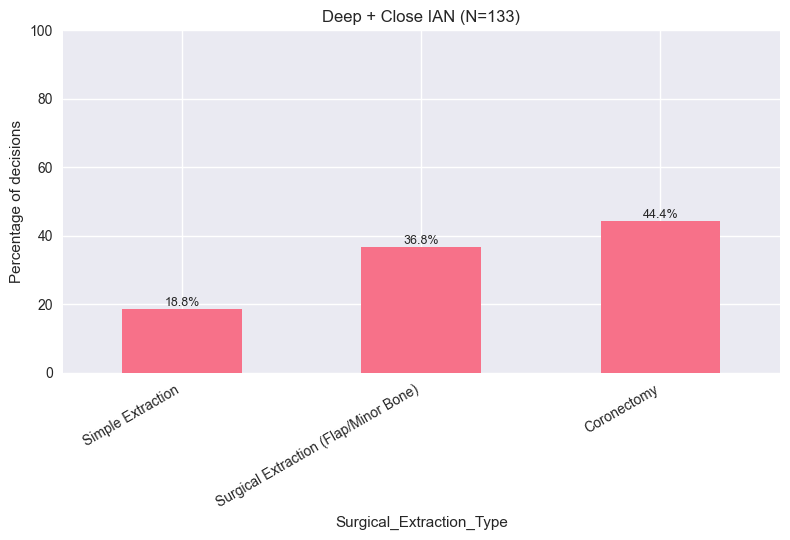


 Deep + NOT Close IAN (N=270)
                                             %  Lift_vs_overall (pp)
Surgical_Extraction_Type                                            
1: Simple Extraction                      25.2                   0.5
2: Surgical Extraction (Flap/Minor Bone)  52.6                   3.3
3: Coronectomy                            22.2                  -3.8


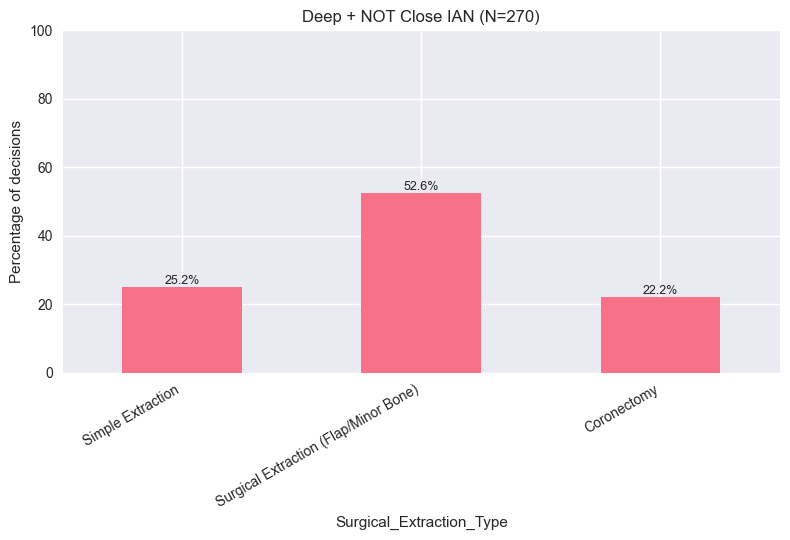


 Horizontal + ≥3 roots (IAN not close) (N=53)
                                             %  Lift_vs_overall (pp)
Surgical_Extraction_Type                                            
1: Simple Extraction                      22.6                  -2.0
2: Surgical Extraction (Flap/Minor Bone)  64.2                  14.9
3: Coronectomy                            13.2                 -12.8


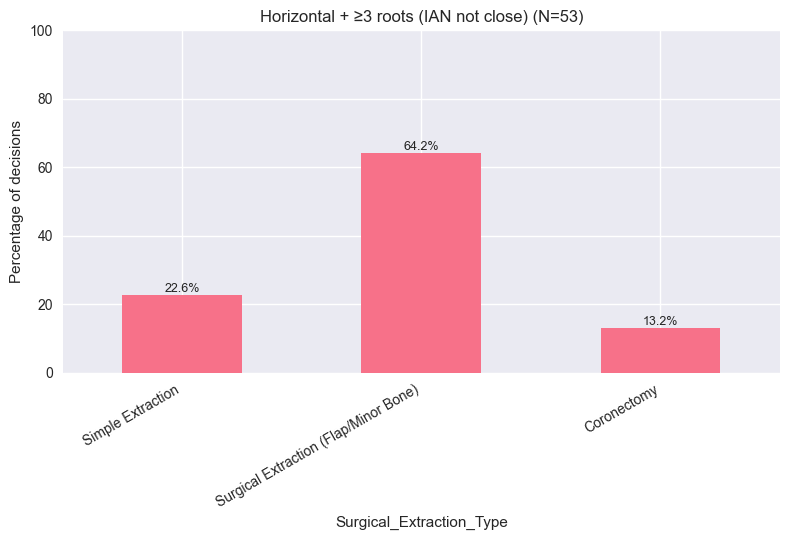


 Horizontal + curvature (IAN not close) (N=75)
                                             %  Lift_vs_overall (pp)
Surgical_Extraction_Type                                            
1: Simple Extraction                      20.0                  -4.6
2: Surgical Extraction (Flap/Minor Bone)  65.3                  16.0
3: Coronectomy                            14.7                 -11.4


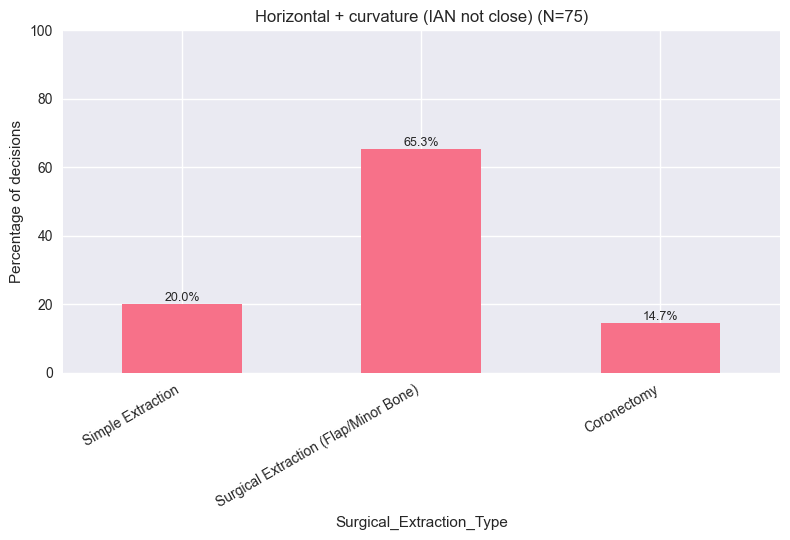


 Swelling + Trismus (N=132)
                                             %  Lift_vs_overall (pp)
Surgical_Extraction_Type                                            
1: Simple Extraction                      17.4                  -7.2
2: Surgical Extraction (Flap/Minor Bone)  57.6                   8.3
3: Coronectomy                            25.0                  -1.1


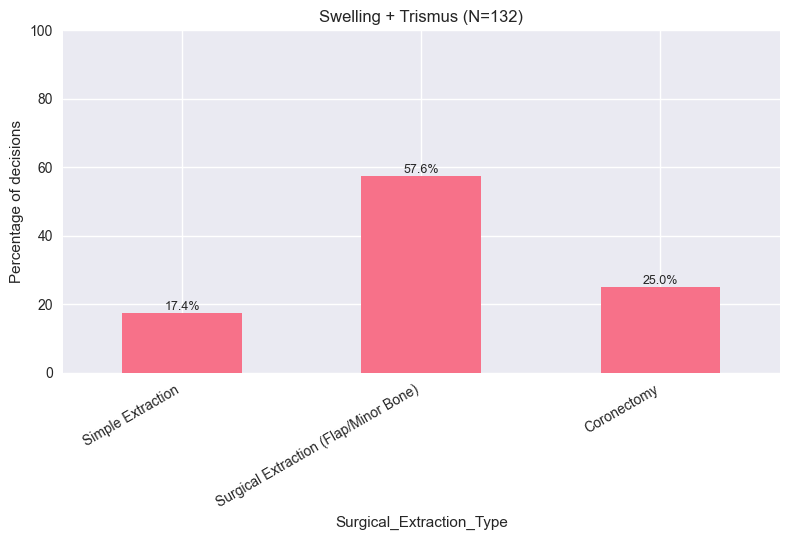


 Cyst + High bone density (N=37)
                                             %  Lift_vs_overall (pp)
Surgical_Extraction_Type                                            
1: Simple Extraction                      18.9                  -5.7
2: Surgical Extraction (Flap/Minor Bone)  37.8                 -11.5
3: Coronectomy                            43.2                  17.2


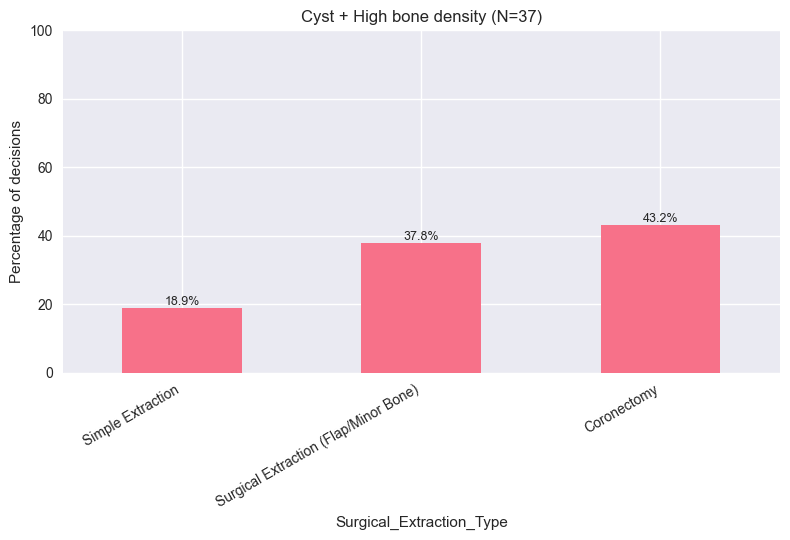


 Complete roots + close IAN (N=424)
                                             %  Lift_vs_overall (pp)
Surgical_Extraction_Type                                            
1: Simple Extraction                      16.7                  -7.9
2: Surgical Extraction (Flap/Minor Bone)  46.9                  -2.4
3: Coronectomy                            36.3                  10.3


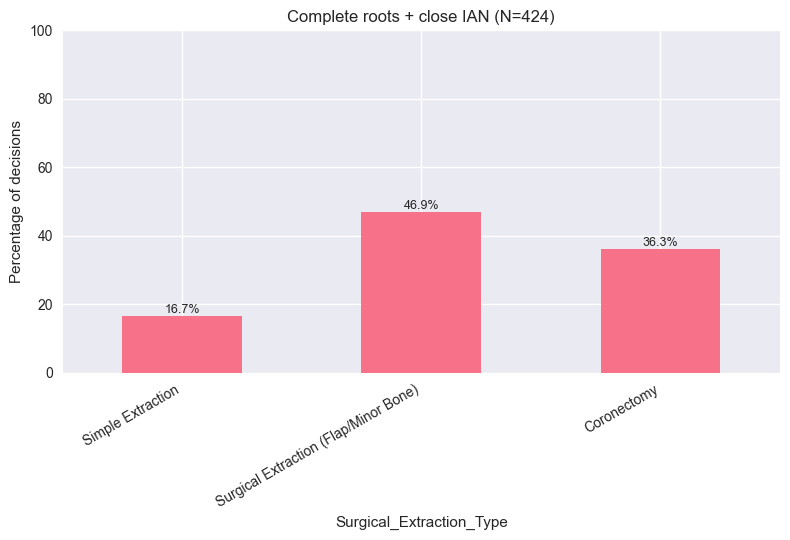


 Severe periodontitis (N=195)
                                             %  Lift_vs_overall (pp)
Surgical_Extraction_Type                                            
1: Simple Extraction                      26.7                   2.0
2: Surgical Extraction (Flap/Minor Bone)  46.7                  -2.6
3: Coronectomy                            26.7                   0.6


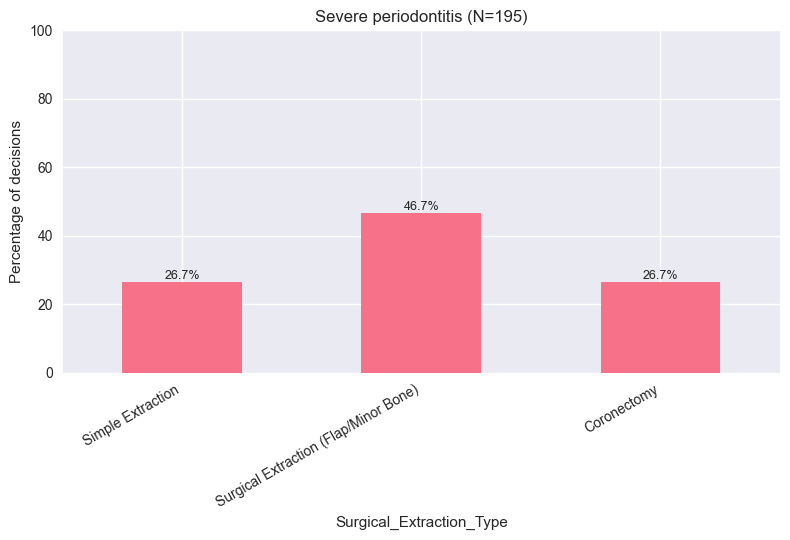

In [27]:
for label, mask in slices:
    slice_distribution(df, mask, label)